# PARTE 1

 MÉRTRICAS DE EVALUACIÓN: LDA
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Matriz de Confusión:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


 MÉRTRICAS DE EVALUACIÓN: K-NN (K=3)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Matriz de Confusión:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


 MÉRTRICAS DE EVALUACIÓN: ÁRBOL DE DECISIÓN
       

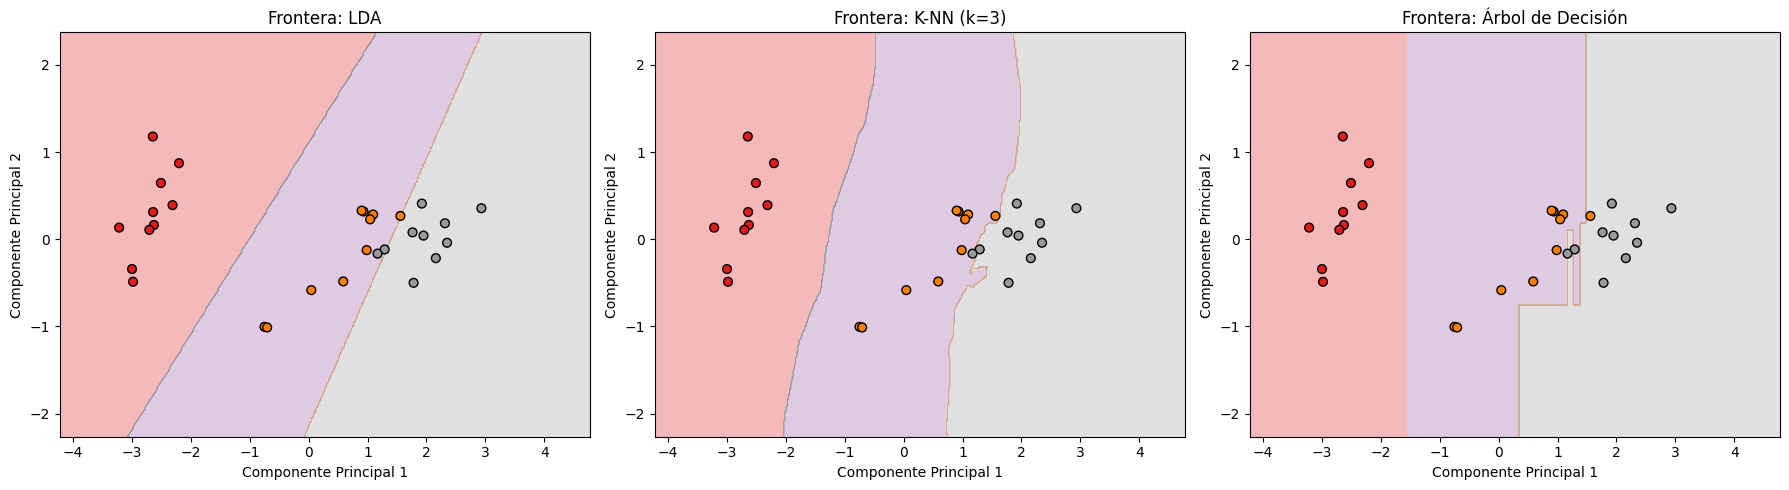

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar datos y reducir dimensiones para visualización 2D
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# 2. Partición de datos (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Definir los clasificadores
models = {
    'LDA': LinearDiscriminantAnalysis(),
    'K-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
}

# 4. Entrenar, evaluar y graficar fronteras de decisión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Configuración de la malla para graficar fronteras
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
)

for ax, (name, model) in zip(axes, models.items()):
    # Entrenamiento
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Imprimir Métricas en consola
    print(f'=' * 50)
    print(f' MÉRTRICAS DE EVALUACIÓN: {name.upper()}')
    print(f'=' * 50)
    print(classification_report(y_test, y_pred, target_names=target_names))
    print('Matriz de Confusión:')
    print(confusion_matrix(y_test, y_pred))
    print('\n')

    # Graficar frontera de decisión
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
    scatter = ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap=plt.cm.Set1,
        edgecolors='k',
        s=40,
    )
    ax.set_title(f'Frontera: {name}')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

# PARTE 2

 METRICAS DE EVALUACION (Partición 40/60)
                         Modelo  Acc Train  Acc Test  F1 Test              Diagnóstico
                   LDA Standard   0.966667  0.977778 0.977778              Equilibrado
          K-NN (k=3) [Adecuado]   0.950000  0.944444 0.944305              Equilibrado
       K-NN (k=7) [Sin Justif.]   0.983333  0.966667 0.966657              Equilibrado
        K-NN (k=45) [Subajuste]   0.666667  0.655556 0.545097 Subajuste (Underfitting)
Árbol (max_depth=1) [Subajuste]   0.666667  0.666667 0.555556 Subajuste (Underfitting)
      Árbol Libre [Sobreajuste]   1.000000  0.900000 0.898620              Equilibrado


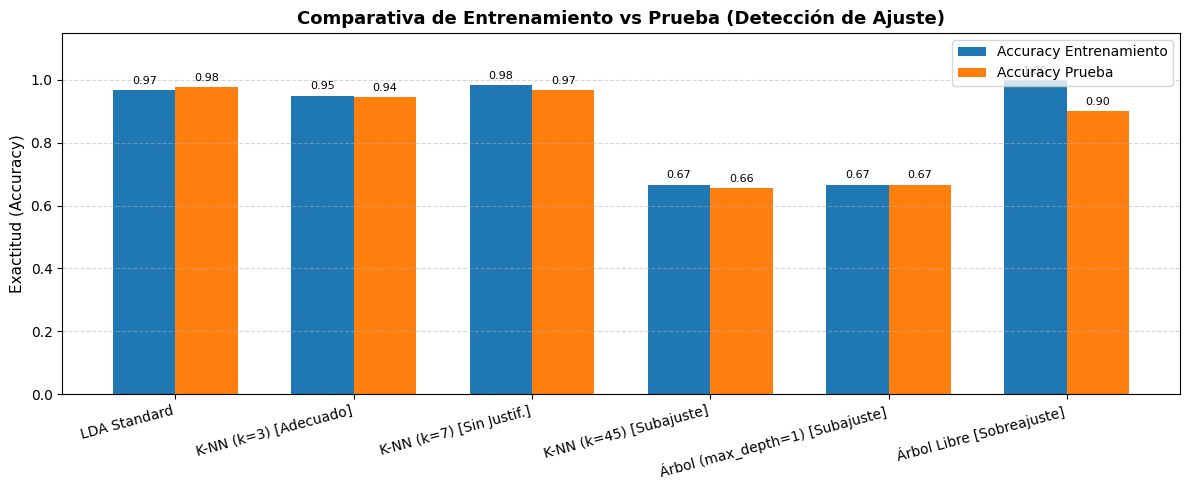

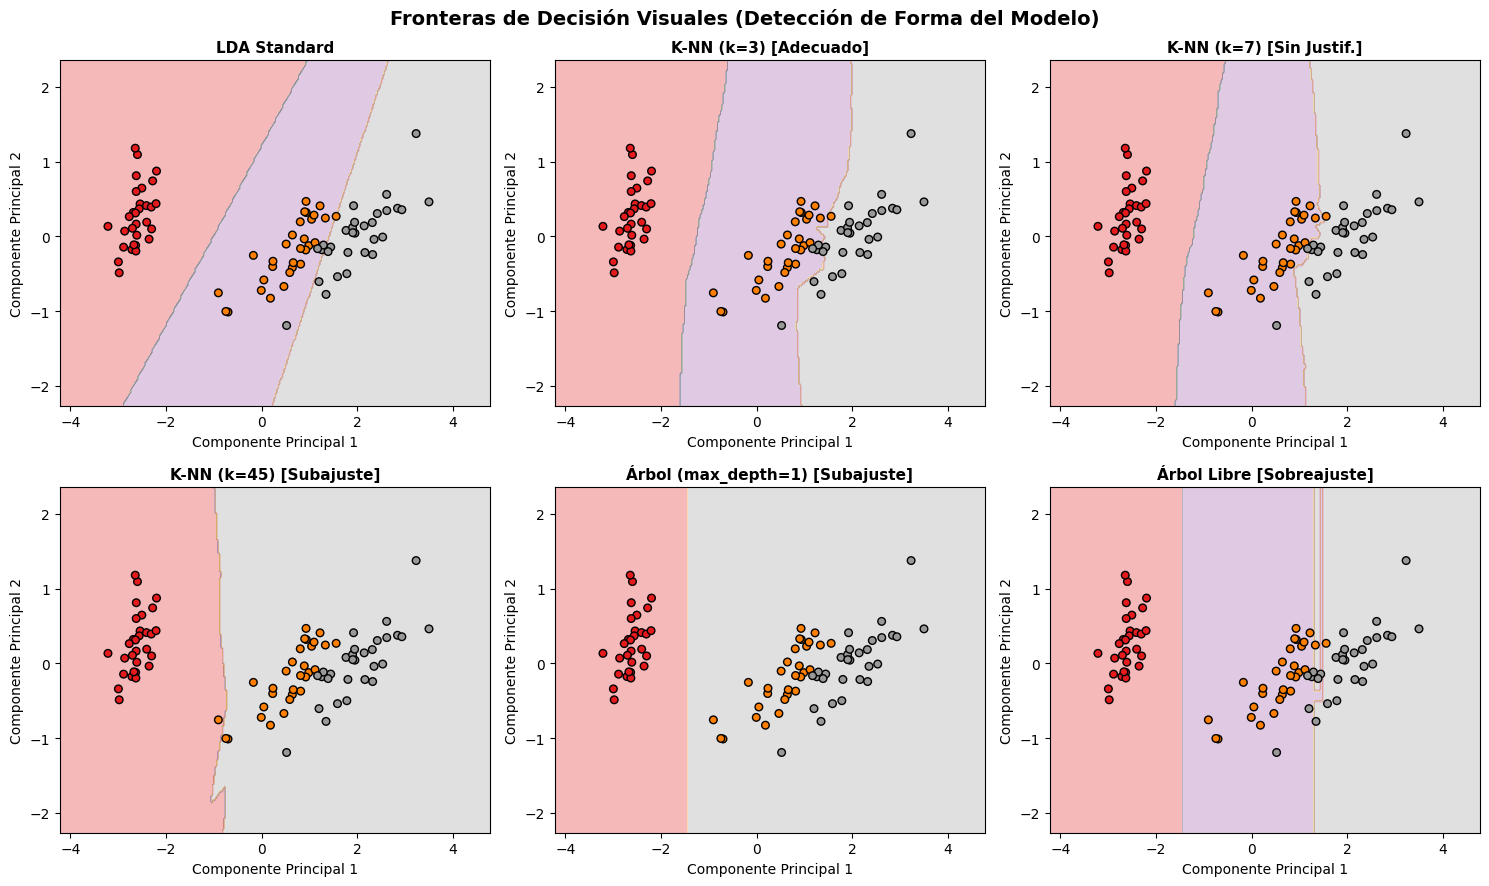

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar datos
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. Definir clasificadores (Incluye modelos balanceados, subajustados y sobreajustados)
models = {
    'LDA Standard': LinearDiscriminantAnalysis(),
    'K-NN (k=3) [Adecuado]': KNeighborsClassifier(n_neighbors=3),
    'K-NN (k=7) [Sin Justif.]': KNeighborsClassifier(n_neighbors=7),
    'K-NN (k=45) [Subajuste]': KNeighborsClassifier(n_neighbors=45),
    'Árbol (max_depth=1) [Subajuste]': DecisionTreeClassifier(
        max_depth=1, random_state=42
    ),
    'Árbol Libre [Sobreajuste]': DecisionTreeClassifier(
        max_depth=None, random_state=42
    ),
}

# 3. Partición de Datos (Evaluando la más crítica: 40% Train / 60% Test)
test_ratio = 0.60
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_ratio, random_state=42, stratify=y
)

# 4. Cálculo de métricas e impresión en consola
results = []
for name, model in models.items():
  model.fit(X_train, y_train)

  acc_train = accuracy_score(y_train, model.predict(X_train))
  acc_test = accuracy_score(y_test, model.predict(X_test))
  f1_test = f1_score(y_test, model.predict(X_test), average='macro')

  diff = acc_train - acc_test
  if acc_train < 0.75 and acc_test < 0.75:
    estado = 'Subajuste (Underfitting)'
  elif diff > 0.10:
    estado = 'Sobreajuste (Overfitting)'
  else:
    estado = 'Equilibrado'

  results.append({
      'Modelo': name,
      'Acc Train': acc_train,
      'Acc Test': acc_test,
      'F1 Test': f1_test,
      'Diagnóstico': estado,
  })

df_results = pd.DataFrame(results)
print('=' * 80)
print(' METRICAS DE EVALUACION (Partición 40/60)')
print('=' * 80)
print(df_results.to_string(index=False))

# ==============================================================================
# FIGURA 1: GRAFICO DE BARRAS COMPARATIVO (TRAIN VS TEST)
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5))
x_locs = np.arange(len(models))
width = 0.35

rects1 = ax.bar(
    x_locs - width / 2,
    df_results['Acc Train'],
    width,
    label='Accuracy Entrenamiento',
    color='#1f77b4',
)
rects2 = ax.bar(
    x_locs + width / 2,
    df_results['Acc Test'],
    width,
    label='Accuracy Prueba',
    color='#ff7f0e',
)

ax.set_ylabel('Exactitud (Accuracy)', fontsize=11)
ax.set_title(
    'Comparativa de Entrenamiento vs Prueba (Detección de Ajuste)',
    fontsize=13,
    fontweight='bold',
)
ax.set_xticks(x_locs)
ax.set_xticklabels(df_results['Modelo'], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Agregar etiquetas sobre las barras
for rect in rects1 + rects2:
  height = rect.get_height()
  ax.annotate(
      f'{height:.2f}',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8,
  )

plt.tight_layout()

# ==============================================================================
# FIGURA 2: FRONTERAS DE DECISION 2D (REDUCCIÓN PCA)
# ==============================================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_tr_pca, X_te_pca, y_tr, y_te = train_test_split(
    X_pca, y, test_size=test_ratio, random_state=42, stratify=y
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

# Malla para límites de decisión
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.03), np.arange(y_min, y_max, 0.03)
)

for idx, (name, model) in enumerate(models.items()):
  model.fit(X_tr_pca, y_tr)
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  ax = axes[idx]
  ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
  scatter = ax.scatter(
      X_te_pca[:, 0],
      X_te_pca[:, 1],
      c=y_te,
      cmap=plt.cm.Set1,
      edgecolors='k',
      s=30,
  )
  ax.set_title(name, fontsize=11, fontweight='bold')
  ax.set_xlabel('Componente Principal 1')
  ax.set_ylabel('Componente Principal 2')

plt.suptitle(
    'Fronteras de Decisión Visuales (Detección de Forma del Modelo)',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()